---
title: "Deelvraag 3"
subtitle: "Evaluatie van een Random Forest-model"
title-block-style: plain
author: "Jalisa Shaline van der Zeeuw"
date: "January 2026"
format:
  pdf:
    geometry: margin=2.5cm
    include-code: false
number-sections: false
execute:
  echo: false
  warning: false
  message: false
---

In [1]:
import sys

EXPECTED_ENV = "ml_oncoresponse"

if EXPECTED_ENV not in sys.prefix:
    print(
        "⚠️ WAARSCHUWING: mogelijk verkeerde conda environment\n"
        f"Verwacht: {EXPECTED_ENV}\n"
        f"Huidig: {sys.prefix}\n"
        "Resultaten kunnen afwijken."
    )

# titel: Analyse van modelprestatie...
[Inleiding]

Deelvraag 3: Hoe goed presteert het getrainde Random Forest-model bij het voorspellen van de drugrespons van longkankercellijnen, gemeten aan de hand van R^2 en RMSE

Het doel is uiteindelijk niet om te kijken welke methode wint, maar om te kijken of de verschillende evaluaties een consistent beeld geven van de performance.

[uitleggen dat ik heb gekozen om te modelleren op `PF-05212384`, hetzelfde geneesmiddel als bij deelvraag 2. Deze keuze is gebaseerd op een combinatie van datacompleetheid, behoud van samplegrootte en de beschikbaarheid van bestaande biologische kennis, wat het mogelijk maakt om modeluitkomsten beter te interpreteren.]

RMSE !
MAE (optioneel)
R^2 (kom ik boven het simpelste model uit?)
Spearman rapporteren (we is gevoeliger dan wie), want specifieke AUC is niet belangrijk bij geneesmiddelen respons..

scatterpot OOB voorspeld vs echt
Bij cross validatie: mean +- SD van RMSE 

Omdat AUC een continue maat is voor geneesmiddelrespons, werd Random Forest regressie geëvalueerd met foutgebaseerde metrics (RMSE, MAE), verklaarde variantie (R²) en rangcorrelatie (Spearman). RMSE werd gebruikt als primaire maat omdat deze direct interpreteerbaar is in AUC-eenheden en grotere voorspellingsfouten zwaarder laat meewegen. Correlatie werd toegevoegd omdat in het kader van geneesmiddelrespons vooral de correcte rangschikking van gevoelige versus ongevoelige cellijnen biologisch relevant is. (waar?)

Figuur 1: OOB voorspeld vs gemeten AUC
Figuur 2: Residuen vs gemeten AUC
Figuur 3: Distributie CV-RMSE (boxplot)?
Figuur: OOB-error vs # bomen (supplement)

## Data-invoer en selectie


Voor deze analyse worden twee datasets gebruikt:  
- X: een pathway-level featurematrix, voorbereid in notebook *dv1_dataprep.ipynb* (`pathway_features.pkl`).  
- y: drug-responsdata, voorbereid in notebook *dataprep_response.ipynb* (`response_matrix.pkl`)

Om datalek te voorkomen worden features `(X)` en respons `(y)` gescheiden ingeladen. Met datalek wordt bedoeld dat het model onbedoeld al toegang krijgt tot informatie die het in de praktijk niet zou hebben. Bijvoorbeeld doordat features zijn gemaakt of geselecteerd met kennis van de drug-respons, of dat bij het trainen gebruik is gemaakt van informatie uit alle data. Hierdoor kan een model beter lijken te preseteren dan het in werkelijkheid zou doen op nieuwe data.

Ter controle wordt eerst de dimensie van beide datasets weergegeven. Vervolgens wordt uit de responsmatrix één geneesmiddel geslecteerd, zoals in de inleiding gemotiveerd is dat in dit geval `PF-05212384`. De bijbehorende AUC-waarden vormen in dit notebook de doelvariabele.

Tot slot worden de twee datasets samengevoegd op basis van de cellijnen. Hierbij worden alleen cellijnen meegenomen waarvoor zowel pathway-kenmerken als geneesmiddelrespons beschikbaar zijn. De resulterende gecombineerde datasets vormt de definitieve dataset die in dit notebook wordt gebruikt voor modeltraining en verdere analyse. (In de code worden deze aangeduid als `X_aligned` en `y_aligned`)

In [4]:
import pandas as pd

# inladen van de datasets
X = pd.read_pickle("../data/processed/pathway_features.pkl")      # featurematrix
y = pd.read_pickle("../data/processed/response_matrix.pkl")      # drug-responsmatrix

# controle shape
print("Featurematrix (X):", X.shape)
print("Responsmatrix (y):", y.shape)


# selecteren van één geneesmiddel
drug_name = "PF-05212384"
y_drug = y[drug_name]

print("Aantal cellijnen met responsdata vóór afstemming:", y_drug.shape[0])

# afstemming van X en y
common_ids = X.index.intersection(y_drug.index)

X_aligned = X.loc[common_ids].copy()
y_aligned = y_drug.loc[common_ids].copy()

print("Aantal cellijnen na afstemming:", X_aligned.shape[0])
print("Aantal features:", X_aligned.shape[1])

# extra controle

assert all(X_aligned.index == y_aligned.index), "Indexen van X en y komen niet overeen!"


Featurematrix (X): (82, 100)
Responsmatrix (y): (93, 1450)
Aantal cellijnen met responsdata vóór afstemming: 93
Aantal cellijnen na afstemming: 82
Aantal features: 100


## Verdeling van de responsvariabele


Voordat het model wordt opgezet, is de ve3rdeling van de AUC-waarden kort verkend. Dit dient als een kwaliteitscontrole om te beoordelen of de respons sterke scheefheid of extreme uitschieters vertoont die van invloed kunnen zijn op de keuze van hyperparameters.

In de figuur hieronder (Figuur 1) is een boxplot weergegeven van de AUC-waarden van het gekozen geneesmiddel, `PF-05212384`.

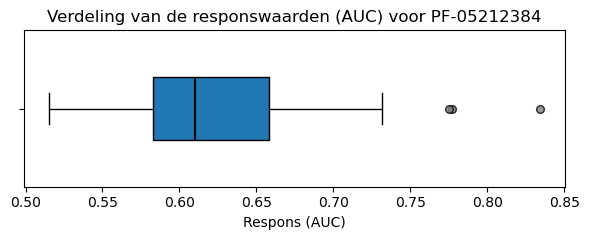

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 2.5))

plt.boxplot(
    y_aligned,
    vert=False,
    patch_artist=True,
    widths=0.4,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(
        marker='o',
        markersize=5.5,
        markerfacecolor='grey',
        markeredgecolor='black',
        alpha=0.8
    )
)

# As-instellingen
plt.yticks([1], [])
plt.xlabel("Respons (AUC)")
plt.title("Verdeling van de responswaarden (AUC) voor PF-05212384")

plt.tight_layout()
plt.show()


***Figuur 1**. Boxplot van de AUC-waarden (n=82) van geneesmiddel PF-05212384.
Minumum = 0.52, maximum = 0.83, gemiddelde = 0.62, mediaan = 0.61, SD = 0.06*

De AUC-waarden liggen in een relatief smal bereik, waarbij het gemiddelde en mediaan dicht bij elkaar liggen. De boxplot toont enkele uitschieters, maar geen sterke scheefheid of extreme waarden. Dit wijst erop dat de responsverdeling geschikt is voor standaard regressiebenaderingen.

## Modelopzet en hyperparameters


In dit notebook wordt Random Forest regressie gebruikt om de relatie tussen pathway-kenmerken en geneesmiddelrespons te modelleren. De keuze voor dit model en de theoretische achtergrond worden uitgebreid besproken in bewijsstuk `model_rf` (zie criterium 1). Hier worden uitsluitend de concrete modelinstellingen beschreven die relevant zijn voor de verdere evaluatie. 

Doel is hier niet op het model maximaal te optimaliseren, maar wel om de gekozen modelinstellingen te motiveren en te onderbouwen zodat de evaluatie betekenisvol is. [laten zien dat ik begrijp wat de parameters doen. Laten zien dat ik dus na denk over mijn keuze in deze parameters en niet blind wat gebruik. --> criteium?]

#### Relevante hyperparameters

Her Random Forest-model kent verschillende instellingen (hyperparameters) die bepalen hoe het model wordt opgebouwd. In dit notebook worden alleen de parameters besproken die de complexiteit en stabiliteit van het model sterk beinvloeden. De beschrijvingen hieronder zijn gebaseerd op de docuentatie van scikit-learn (RandomForestRegressor)[https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html?_x_tr_sl=en&_x_tr_tl=nl&_x_tr_hl=nl&_x_tr_pto=sc]

**Aantal bomen (`n_estimators`)**

Deze parameter bepaalt uit hoeveelbeslissingsbomen het RF-model bestaat. Meer bomen leiden tot stabielere en minder toevallige voorspellingen, maar verhogen ook de rekentijd. 

**Maximale boomdiepte (`max_depht`)**  
Deze parameter bepaalt hoe diep elke beslissingsboom mag worden. Diepere bomen kunnen complexere patronen leeren, maar hebben ook een grotere kans om zich te veel aan te passen aan trainingsdata (overfitting). Door maximale diepte te beperken kan het model worden gedwongen om meer algemene patronen te leren.

**Aantal features per splitsing (`max_features`)**  
Bij elke splitsing in een boom wordt slechts een deel van alle beschikbare features overwogen. Een kleinere waarde zorgt ervoor dat bij elke splitsing slechts een willekeurige subset van kenmerken wordt overwogen. Hierdoor worden de individuele bomen meer van elkaar verschillend, wat de stabiliteit van het forest vergroot en kans op overfitting verkleint.

**Minimale grootte van eindknopen(`min_samples_leaf)`**  
Deze parameter bepaalt hoeveel cellijnen minimaal in een eindknoop aanwezig moeten zijn. Hogere waarden waarden voorkomen dat bomen zich volledig aanpassen aan zeer kleine groepen of individuele uitschieters. Dit vermindert de kans dat toevallige patronen in een kleine dataset worden geleerd, maar kan ten koste gaan van het modelleren van zeldzame effecten.

**Splitsingscriterium(`squared_error`)**  
Als splitsingscriterium wordt de standaardinstelling gebruikt. Hierbij worden splitsingen gekozen die de spreiding van AUC-waarden binnen de resulterende groep zo klein mogelijk maken, waarbij grote fouten extra zwaar meetellen. Dit criterium is geschikt voor continue responsmaten zoals AUC en sluit aan bij de gebruikte evaluatiemetric RMSE. 

## Verkenning en keuze van hyperparameters


In deze sectie wordt in beperkte mate verkend hoe enkele kerninstellingen van het Random Forest-model het gedrag en de stabiliteit van het model beïnvloeden. Het doel is niet om het model maximaal te optimaliseren, maar om te controleren of de gekozen instellingen leiden tot stabiele en redelijke prestaties. Hiervoor wordt gebruiktgemaakt van de out-of-bag (OOB) fout als interne schatting van de modelprestatie. 

Op basis van deze verkenning worden vervolgens de instellingen vastgelegd die in de verdere modelevaluatie worden gebruikt.


**Startmodel en eerste OOB-evaluatie**  

Om te beginnen wordt een Random Forest-model met standaardinstellingen getraind. Dit model dient als uitgangspunt voor verdere verkenning.

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf_start = RandomForestRegressor(
    n_estimators=300,
    criterion="squared_error",
    max_features="sqrt",
    max_depth=None,
    min_samples_leaf=1,
    oob_score=True,
    random_state=17,
    n_jobs=-1
)

rf_start.fit(X_aligned, y_aligned)

# OOB voorspellingen
oob_pred = rf_start.oob_prediction_

# OOB RMSE
oob_rmse = np.sqrt(mean_squared_error(y_aligned, oob_pred))

# overzicht van belangrijkste instellingen van het startmodel
print("Startmodel instellingen:")
print("Aantal bomen (n_estimators):", rf_start.n_estimators)
print("Max features per splitsing (max_features):", rf_start.max_features)
print("Maximale boomdiepte (max_depth):", rf_start.max_depth)
print("Minimale bladgrootte (min_samples_leaf):", rf_start.min_samples_leaf)
print("Splitsingscriterium (criterion):", rf_start.criterion)
print("Out-of-bag evaluatie (oob_score):", rf_start.oob_score)
print()
print("OOB RMSE (startmodel):", round(oob_rmse, 4))


Startmodel instellingen:
Aantal bomen (n_estimators): 300
Max features per splitsing (max_features): sqrt
Maximale boomdiepte (max_depth): None
Minimale bladgrootte (min_samples_leaf): 1
Splitsingscriterium (criterion): squared_error
Out-of-bag evaluatie (oob_score): True

OOB RMSE (startmodel): 0.0616


Het startmodel resulteert in een OOB RMSE van 0.0616. Deze waarde wordt gebruikt als referentiepunt bij de verkenning van hyperparameters.

In de volgende stap wordt gekeken of het aantal bomen in het model voldoende is. Het Random Forest-model wordt getraind met verschillende aantallen bomen, terwijl alle overige instellingen gelijk blijven. 

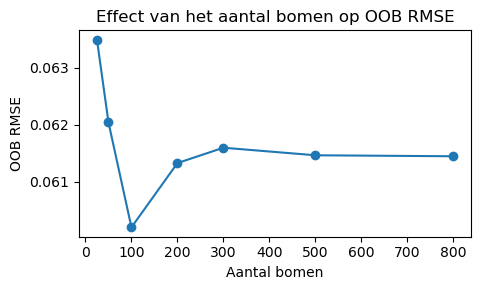

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

n_estimators_list = [25, 50, 100, 200, 300, 500, 800]
oob_rmse_list = []

for n in n_estimators_list:
    rf = RandomForestRegressor(
        n_estimators=n,
        criterion="squared_error",
        max_features="sqrt",
        max_depth=None,
        min_samples_leaf=1,
        oob_score=True,
        random_state=17,
        n_jobs=-1
    )
    
    rf.fit(X_aligned, y_aligned)
    oob_pred = rf.oob_prediction_
    oob_rmse = np.sqrt(mean_squared_error(y_aligned, oob_pred))
    oob_rmse_list.append(oob_rmse)

# Plot
plt.figure(figsize=(5,3))
plt.plot(n_estimators_list, oob_rmse_list, marker='o')
plt.xlabel("Aantal bomen")
plt.ylabel("OOB RMSE")
plt.title("Effect van het aantal bomen op OOB RMSE")
plt.tight_layout()
plt.show()


***Figuur 2**. Out-of-bag RMSE als functie van het aantal bomen in het Random Forest-model. Voor elk aantal bomen is het model opnieuw getraind met identieke instellingen, waarbij de OOB-samples zijn gebruikt om de voorspellings te schatten.*

De OOB RMSE daalt nog licht bij het verhogen van het aantal bomen tot ongeveer 100. Bij verdere verhoging blijft de fout stabiel en schommelt deze rond een vergelijkbare waarde. Dit wijst erop dat de prestaties vanaf circa 100 bomen stabiel zijn. Op basis hiervan is gekozen om de `n_estimators` in te stellen op 300 bomen, wat ruim binnen het stabiele gebied ligt.

Nu is vastgesteld dat het model stabiele prestaties toont, wil ik kijken naar een tweede hyperparameter die direct invloed heeft op de complexiteit van het model. Omdat de dataset relatief klein is (n=82) en biologische data gevoelig kan zijn voor ruis, is het relevant om te onderzoeken in hoeverre het model zich aanpast aan zeer kleine groepen obervaties. Dit wordt verkend met de parameter `min_samples_leaf`.

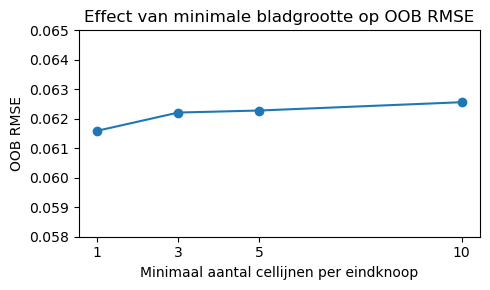

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

leaf_sizes = [1, 3, 5, 10]
oob_rmse_leaf = []

for leaf in leaf_sizes:
    rf = RandomForestRegressor(
        n_estimators=300,
        criterion="squared_error",
        max_features="sqrt",
        max_depth=None,
        min_samples_leaf=leaf,
        oob_score=True,
        random_state=17,
        n_jobs=-1
    )
    
    rf.fit(X_aligned, y_aligned)
    oob_pred = rf.oob_prediction_
    oob_rmse = np.sqrt(mean_squared_error(y_aligned, oob_pred))
    oob_rmse_leaf.append(oob_rmse)
    

# Plot
plt.figure(figsize=(5,3))
plt.plot(leaf_sizes, oob_rmse_leaf, marker='o')
plt.xlabel("Minimaal aantal cellijnen per eindknoop")
plt.ylabel("OOB RMSE")
plt.title("Effect van minimale bladgrootte op OOB RMSE")
plt.xticks(leaf_sizes)
plt.ylim(0.058, 0.065)
plt.tight_layout()
plt.show()


***Figuur 3**. Out-of-bag RMSE bij verschillende waarden voor de minimale bladgrootte (`min_samples_leaf`). De OOB RMSE varieert slechts beperkt tussen 0.0616 en 0.0623, wat wijst op een minimale gevoeligheid van het model voor deze parameter.*

De OOB RMSE verschilt slechts minimaal tussen de geteste waarden voor `min_samples_leaf`. Hogere waarden leiden niet tot een verbetering van de prestatie, maar eerder tot een lichte verslechtering. Dit wijst erop dat het model bij de standaardinstelling geen tekenen van overfitting vertoont.

Hogere waarden voor `min_samples_leaf` beperken het model, omdat splitsingen op kleine groepen cellijnen dan niet meer zijn toegestaan. Hierdoor kan mogelijk informatie verloren gaan en kunnen minder patronen worden geleerd. Omdat meer cellijnen per eindknoop in deze analyse geen verbetering oplevert, is gekozen voor de minst beperkende instelling (`min_samples_leaf` = 1).


#### Conclusie hyperparameterverkenning

In deze sectie is onderzocht of het startmodel voldoende stabiele en redelijke prestaties vertoont, en of aanpassing van kerninstellingen noodzakelijk is. Uit de analyse blijkt dat de OOB RMSE stabiliseert bij hogere aantallen bomen en dat het model slechts beperkt gevoelig is voor de minimale bladgrootte. Er zijn geen aanwijzingen gevonden dat het model instabiel is of zich te sterk aanpast aan kleine groepen observaties. Op basis van deze bevindingen wordt het startmodel gehandhaafd als definities model voor de verdere evaluatie.

## Definitief model voor evaluatie

Op basis van de voorgaande sectie is één Random Forest-model vastgelegd dat in de rest van dit notebook wordt gebruikt voor de modelevaluatie. In onderstaande tabel zijn de belangrijkste instellingen van dit model weergegeven.  

***Tabel 1.** Overzicht van de belangrijkste instellingen van het definitieve Random Forest-model.*

In [47]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# definitief RF-model
rf_final = RandomForestRegressor(
    n_estimators=300,
    criterion="squared_error",
    max_features="sqrt",
    max_depth=None,
    min_samples_leaf=1,
    oob_score=True,
    random_state=17,
    n_jobs=-1
)

# train model
rf_final.fit(X_aligned, y_aligned)

# Tabel met relevante instellingen
params = {
    "Aantal bomen (n_estimators)": rf_final.n_estimators,
    "Splitsingscriterium": rf_final.criterion,
    "Max features per splitsing": rf_final.max_features,
    "Maximale boomdiepte": rf_final.max_depth,
    "Minimale bladgrootte": rf_final.min_samples_leaf,
    "Out-of-bag evaluatie": rf_final.oob_score,
    "Random seed": rf_final.random_state
}

params_df = pd.DataFrame.from_dict(params, orient="index", columns=["Waarde"])
params_df

,Waarde
Aantal bomen (n_estimators),300
Splitsingscriterium,squared_error
Max features per splitsing,sqrt
Maximale boomdiepte,None
Minimale bladgrootte,1
Out-of-bag evaluatie,True
Random seed,17


## Modelevaluatie

eerst inschatting van prestaties met visueel beeld.
OOB evaluatie
    RMSE, R2, correlatie
    scatterplot: voorspeld vs gemeten 
Cross-validatie
    opzet
    boxplot
    vergelijking mer OOB?





In [ ]:
Cross validatie 
    5fold CV
    per fold RMSE, (MAE), R2
    boxplot van prestaties
doel is stabiliteit en spreiding van prestaties

OOB met CV vergelijken 


# Interpretatie en beperkingen

voorspelbaarheid
stabiliteit
kleine n benoemen
biologisch?
bruikbaarheid van dit model
